In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras as keras
from tensorflow.keras import layers
from pathlib import Path
import matplotlib.pyplot as plt

2026-04-28 13:41:38.254350: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 13:41:38.263042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-28 13:41:38.270981: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-28 13:41:38.273543: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-28 13:41:38.282586: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Data paths and parameters
train_dir = Path(r'/dataset/Fish_Dataset_clean')
img_size = (224, 224)
batch_size = 32
project_root = Path(r'C:\Users\anton\Documents\Workspaces\GitHubDesktop\Image-Classification-Explainability')

In [3]:
train_datagen = ImageDataGenerator(
    rescale = 1.0 / 255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 7201 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.
Number of classes: 9
Training samples: 7201
Validation samples: 1800


In [4]:
inputs = keras.Input(shape=(224, 224, 3))

x = layers.Conv2D(64, 3, activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(256, 3, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(512, 3, activation="relu")(x)
x = layers.BatchNormalization()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

model = Model(inputs=inputs, outputs=outputs)

print(f"\\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

I0000 00:00:1777383700.814687     428 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1777383700.861893     428 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1777383700.861929     428 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1777383700.863922     428 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1777383700.863978     428 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

\nTotal parameters: 1,588,233
Trainable parameters: 1,586,313
Non-trainable parameters: 1,920


In [5]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = ModelCheckpoint(
    "baseline_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [6]:
# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint_cb]
)

Epoch 1/20


2026-04-28 13:41:42.947795: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1777383703.194205     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383703.211537     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383703.231131     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383703.232538     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383703.234116     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383703.236400     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383703.257700     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383703.260479     548 gpu_

  1/226 [..............................] - ETA: 13:53 - loss: 2.2785 - accuracy: 0.0938

W0000 00:00:1777383705.228220     542 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383705.229904     542 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383705.231694     542 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383705.234028     542 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383705.235886     542 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383705.237522     542 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383705.239454     542 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383705.241523     542 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777383705.244113     542 gp

  2/226 [..............................] - ETA: 2:02 - loss: 2.2898 - accuracy: 0.1250 

...

226/226 [==============================] - ETA: 0s - loss: 0.0050 - accuracy: 0.9992
Epoch 12: val_loss did not improve from 0.45703
226/226 [==============================] - 62s 276ms/step - loss: 0.0050 - accuracy: 0.9992 - val_loss: 0.5728 - val_accuracy: 0.8756
Epoch 13/20
196/226 [=========================>....] - ETA: 6s - loss: 0.0340 - accuracy: 0.9895

W0000 00:00:1777384507.870432     541 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384507.870667     541 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384507.870808     541 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384507.871126     541 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384507.871358     541 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384507.871598     541 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384507.871827     541 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384507.872051     541 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384507.872353     541 gp

226/226 [==============================] - ETA: 0s - loss: 0.0364 - accuracy: 0.9886
Epoch 13: val_loss did not improve from 0.45703
226/226 [==============================] - 62s 276ms/step - loss: 0.0364 - accuracy: 0.9886 - val_loss: 24.3869 - val_accuracy: 0.1144
Epoch 14/20
153/226 [===================>..........] - ETA: 16s - loss: 0.0314 - accuracy: 0.9902

W0000 00:00:1777384560.786285     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384560.786511     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384560.786911     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384560.787066     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384560.787236     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384560.787496     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384560.787742     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384560.787963     548 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777384560.788350     548 gp

226/226 [==============================] - ETA: 0s - loss: 0.0345 - accuracy: 0.9890
Epoch 14: val_loss did not improve from 0.45703
226/226 [==============================] - 64s 285ms/step - loss: 0.0345 - accuracy: 0.9890 - val_loss: 2.5520 - val_accuracy: 0.5483
Epoch 15/20
226/226 [==============================] - ETA: 0s - loss: 0.0426 - accuracy: 0.9864
Epoch 15: val_loss did not improve from 0.45703
226/226 [==============================] - 63s 277ms/step - loss: 0.0426 - accuracy: 0.9864 - val_loss: 2.2132 - val_accuracy: 0.6444
Epoch 16/20
226/226 [==============================] - ETA: 0s - loss: 0.0093 - accuracy: 0.9972
Epoch 16: val_loss did not improve from 0.45703
226/226 [==============================] - 62s 275ms/step - loss: 0.0093 - accuracy: 0.9972 - val_loss: 0.7858 - val_accuracy: 0.8172
Epoch 17/20
226/226 [==============================] - ETA: 0s - loss: 0.0017 - accuracy: 1.0000
Epoch 17: val_loss did not improve from 0.45703
226/226 [=====================

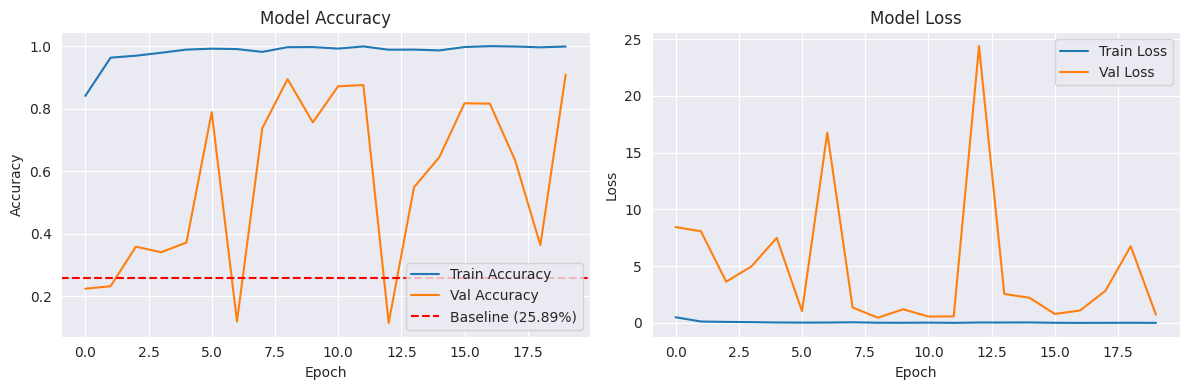

In [7]:
# Visualize training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.axhline(y=0.2589, color='r', linestyle='--', label='Baseline (25.89%)')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# Results summary
best_val_acc = max(history.history['val_accuracy'])
final_val_acc = history.history['val_accuracy'][-1]
baseline_acc = 0.2589

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Baseline validation accuracy:     {baseline_acc:.4f} (25.89%)")
print(f"Current best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Final validation accuracy:        {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Improvement over baseline:        {(best_val_acc - baseline_acc):.4f} ({(best_val_acc - baseline_acc)*100:.2f}%)")
print("=" * 60)

if best_val_acc > baseline_acc:
    print("✓ Architecture improved performance!")
else:
    print("✗ No improvement - try different architecture")

RESULTS SUMMARY
Baseline validation accuracy:     0.2589 (25.89%)
Current best validation accuracy: 0.9089 (90.89%)
Final validation accuracy:        0.9089 (90.89%)
Improvement over baseline:        0.6500 (65.00%)
✓ Architecture improved performance!


In [9]:
# # Save model if improved
# if best_val_acc > baseline_acc:
#     save_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Improved.keras'
#     model.save(save_path)
#     print(f'✓ Model saved to: {save_path}')
# else:
#     print('Model not saved (no improvement over baseline)')

In [10]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 64)      1792      
                                                                 
 batch_normalization (Batch  (None, 222, 222, 64)      256       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 64)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 128)     73856     
                                                                 
 batch_normalization_1 (Bat  (None, 109, 109, 128)     512   